# set up

In [1]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [178]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
# sns.set_theme()
sns.set_theme(style="white")
# sns.set_style('whitegrid')

from scipy.stats import wilcoxon, ranksums
from numpy import matlib
from scipy.stats.distributions import chi2
from sklearn.model_selection import KFold

In [3]:
# Load selected group_id
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [4]:
# Load data
start_time = 0.0
end_time = 0.50
padding = 0.3
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
#                    stimulus_condition_id=[246, 247, 248, 249, 250, 251, 252, 253, 255, 256, 257, 258, 259, 260, 261, 
#                                           262, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 276, 277,
#                                           278, 279, 280, 281, 282, 283, 284, 285, 286, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


In [739]:
def getI(features, dt, nt, npadding):
    time_line = np.arange(-npadding, nt)*dt
    baseline = features["baseline"]
    features["I"] = np.zeros((len(time_line), features["bump_center"][0].shape[0]))+baseline
    for i in range(len(features["bump_amp"])):
        stimulus = (features["bump_amp"][i])*np.exp(-((time_line[:, np.newaxis]- \
                       features["bump_center"][i][np.newaxis, :])/features["bump_wid"][i])**2)
        features["I"] += stimulus

In [779]:
def getI(features, dt, nt, npadding):
    time_line = np.arange(-npadding, nt)*dt
    baseline = features["baseline"]
    features["I"] = np.zeros((len(time_line), features["bump_center"][0].shape[0]))+baseline
    for i in range(len(features["bump_amp"])):
        stimulus = np.zeros((len(time_line), features["bump_center"][0].shape[0]))
        stimulus_pre = (features["bump_amp"][i])*np.exp(-((time_line- \
                       features["bump_pre_center"][i])/features["bump_wid"][i])**2)
        for itrial in range(features["bump_center"][0].shape[0]):
            if i==0:
                stimulus[:,itrial] =  GLM.linear_time_warping_single(time_line, stimulus_pre, 
                    [0, features["bump_pre_center"][i], 1500], [0, features["bump_center"][i][itrial], 1500], verbose=False)
            else:
                stimulus[:,itrial] =  GLM.linear_time_warping_single(time_line, stimulus_pre, 
                    [1500, features["bump_pre_center"][i], 3500], [1500, features["bump_center"][i][itrial], 3500], verbose=False)
        features["I"] += stimulus

In [787]:
source = {"baseline": 0, 
          "bump_pre_center": [50,250], 
          "bump_amp": [2.5,2.5], 
          "bump_wid": [15,15],
          "bump_center": np.nan}
std1 = 20
corr1 = 0.8
std2 = 20
corr2 = 0.8
bump_center_mean1 = [50, 70]
bump_center_cov1 = np.array([[std1**2, corr1*std1**2], [corr1*std1**2, std1**2]])
#     bump_center_cov1 = np.array([[0, 0], [0, 0]])
bump_center_mean2 = [250, 260]
bump_center_cov2 = np.array([[std2**2, corr2*std2**2], [corr2*std2**2, std2**2]])
#     bump_center_cov2 = np.array([[0, 0], [0, 0]])
bump_centers1 = np.random.multivariate_normal(bump_center_mean1, bump_center_cov1, size=ntrial)
bump_centers2 = np.random.multivariate_normal(bump_center_mean2, bump_center_cov2, size=ntrial)
source["bump_center"] = [bump_centers1[:, 0], bump_centers2[:, 0]]
target["bump_center"] = [bump_centers1[:, 1], bump_centers2[:, 1]]

getI(source, 0.1, 5000, 500)

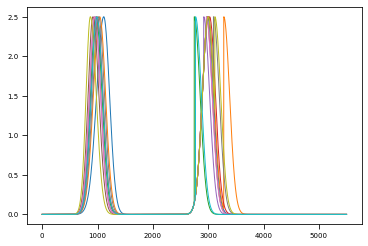

In [788]:
plt.plot(source["I"][:,:10])

In [807]:
def EIF_simulator():
    ntrial = 100
    nneuron = 20
    dt = 0.1
    ndt = int(1/dt)
    padding = 50
    nt = (500)*ndt
    padding = 50
    npadding = padding*ndt
    nt_tot = nt + npadding
    noise_amp = 1

    J = np.zeros((nneuron, nneuron)) # From row i to column j
    nneuron_part = int(nneuron/2)
    J[0:nneuron_part,nneuron_part:] = 0.0
    J[0:nneuron_part,0:nneuron_part] = 0.0
    J[nneuron_part:,nneuron_part:] = 0.0

    baseline = 0.0
    bump_amp = 0.05
    bump_wid = 15
    std1 = 10
    corr1 = 0.8
    std2 = 20
    corr2 = 0.8
    bump_center_mean1 = [50, 70]
    bump_center_cov1 = np.array([[std1**2, corr1*std1**2], [corr1*std1**2, std1**2]])
#     bump_center_cov1 = np.array([[0, 0], [0, 0]])
    bump_center_mean2 = [250, 260]
    bump_center_cov2 = np.array([[std2**2, corr2*std2**2], [corr2*std2**2, std2**2]])
#     bump_center_cov2 = np.array([[0, 0], [0, 0]])
    bump_centers1 = np.random.multivariate_normal(bump_center_mean1, bump_center_cov1, size=ntrial)
    bump_centers2 = np.random.multivariate_normal(bump_center_mean2, bump_center_cov2, size=ntrial)
    
    source = {"baseline": baseline, 
              "bump_pre_center": [bump_center_mean1[0],bump_center_mean2[0]], 
              "bump_center": [np.nan,np.nan], 
              "bump_amp": [bump_amp,bump_amp], 
              "bump_wid": [bump_wid,bump_wid]}
    target = {"baseline": baseline, 
              "bump_pre_center": [bump_center_mean1[1],bump_center_mean2[1]], 
              "bump_center": [np.nan,np.nan], 
              "bump_amp": [bump_amp,bump_amp], 
              "bump_wid": [bump_wid,bump_wid]}
    source["bump_center"] = [bump_centers1[:, 0], bump_centers2[:, 0]]
    target["bump_center"] = [bump_centers1[:, 1], bump_centers2[:, 1]]
    getI(source, dt, nt, npadding)
    getI(target, dt, nt, npadding)
    I_ext = 0.0*np.ones((nt_tot, nneuron, ntrial))
    I_ext[:,:nneuron_part,:] = np.repeat(source["I"][:,np.newaxis,:],nneuron_part, axis=1)
    I_ext[:,nneuron_part:,:] = np.repeat(target["I"][:,np.newaxis,:],nneuron_part, axis=1)
#     I_ext += np.random.normal(0,10,I_ext.shape)

    # Unit: mV or ms
    tau = 15
    EL = -60
    VT = -50
    Vth = -10
    Vre = -65
    DltT = 2
    tau_ref = 1
    tau_d = 5
    tau_r = 1

    nsyn_func = 3*tau_d*ndt
    syn_time_line = np.arange(nsyn_func)
    syn_func = (np.exp(-syn_time_line*dt/tau_d)-np.exp(-syn_time_line*dt/tau_r))[:, np.newaxis]
    ntau_ref = tau_ref*ndt
    V_rcd = np.zeros((nt_tot, nneuron, ntrial))
    I_rcd = np.zeros((nt_tot+nsyn_func+1, nneuron, ntrial))
    spikes_rcd = np.zeros((nt_tot, nneuron, ntrial))

    for itrial in range(ntrial):
        V = Vre*np.ones((nt_tot, nneuron))
        I_syn = np.zeros((nt_tot+nsyn_func+1, nneuron))
        spikes = np.zeros((nt_tot, nneuron))

        for t in range(1, nt_tot):

            I_leak = -dt/tau*(V[t-1,:]-EL) + dt/tau*DltT*np.exp((V[t-1,:]-VT)/DltT)
            I_noise = np.random.normal(0, noise_amp**2, nneuron)
            dV = I_leak + I_noise + I_syn[t,:] + I_ext[t,:,itrial]
            V[t,:] = V[t-1,:] + dV

            spikes[t,:] = (V[t,:]>=Vth).astype(int)
            I_syn[(t+1):(t+nsyn_func+1),:] += spikes[t:(t+1),:]@J*syn_func

            in_ref = ((spikes[max(0,t-ntau_ref):(t+1),:].sum(axis=0))>0).astype(int)
            V[t,:] += in_ref*(Vre-V[t,:])

        V_rcd[:,:,itrial] = V
        I_rcd[:,:,itrial] = I_syn
        spikes_rcd[:,:,itrial] = spikes

    spikes_rcd = spikes_rcd.reshape((int(nt_tot/ndt),ndt,nneuron,ntrial), order='C').sum(axis=1)
    return spikes_rcd[padding:,:,:]

spikes_rcd = EIF_simulator()

# Fit the two methods for 100 times

In [ ]:
ntimes = 1
nfold = 10
penalty = 1e5
penalty_pop = 0.5e5
num = 40
num_pop = num
peaks_max = 15

tau = 10
num_f_refractory = 4

result = []
result_pop = []

for itimes in tqdm(range(ntimes)):
    test_nll_full = []
    test_nll_nest = []
    test_nll_full_pop = []
    test_nll_nest_pop = []
    nll_diff = 0
    nll_diff_pop = 0
    
    if itimes!=1:
        spikes_rcd = EIF_simulator()
    nt, nneuron, ntrial = spikes_rcd.shape
    
    spike_trains_source = []
    spike_trains_target = []
    time_line = np.arange(nt)
    
    for ineuron in range(nneuron):
        if ineuron < int(nneuron/2):
            spike_trains_source.append(spikes_rcd[:,ineuron,:])
        else:
            spike_trains_target.append(spikes_rcd[:,ineuron,:])
    
    kf = KFold(n_splits=nfold)
    for ifold, (train_index, test_index) in enumerate(kf.split(np.ones(ntrial))):
        
        training_trials = np.array( [False]*ntrial )
        training_trials[train_index] = True
        test_trials = np.logical_not(training_trials)

        ### Single neuron level model
        for output_spike_train in spike_trains_target:

            model_full = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_full.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
            for input_spike_train in spike_trains_source:
                model_full.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=peaks_max, nonlinear=1)
            for input_spike_train in spike_trains_target:
                model_full.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=peaks_max, nonlinear=1)
            model_full.fit(target=output_spike_train, method='mine', penalty=penalty, verbose=False)
            test_nll_full.append( model_full.test(test_trials) )

            model_nest = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_nest.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
            for input_spike_train in spike_trains_target:
                model_nest.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=peaks_max, nonlinear=1)
            model_nest.fit(target=output_spike_train, method='mine', penalty=penalty, verbose=False)
            test_nll_nest.append( model_nest.test(test_trials) )
            nll_diff += model_nest.nll - model_full.nll

        ### Population level model
        output_spike_train_pool = np.zeros((nt, ntrial))
        for output_spike_train in spike_trains_target:
            output_spike_train_pool += output_spike_train
        input_spike_train_pool = np.zeros((nt, ntrial))
        for input_spike_train in spike_trains_source:
            input_spike_train_pool += input_spike_train

        model_full_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_full_pop.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
        model_full_pop.add_effect("coupling", raw_input=input_spike_train_pool, num=3, peaks_max=peaks_max, nonlinear=1)
        model_full_pop.add_effect("coupling", raw_input=output_spike_train_pool, num=3, peaks_max=peaks_max, nonlinear=1)
        model_full_pop.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
                                  num=num_f_refractory, apply_no_penalty=False)
#         model_full_pop.fit(target=output_spike_train_pool, method='mine', penalty=penalty_pop, verbose=False)
        model_full_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=20, 
                                                 warp_interval=[[0, 0.15],[0.15, 0.35]], 
                                                 method='mine', penalty=penalty_pop, verbose=False)
        test_nll_full_pop.append( model_full_pop.test(test_trials) )

        model_nest_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_nest_pop.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
        model_nest_pop.add_effect("coupling", raw_input=output_spike_train_pool, num=3, peaks_max=peaks_max, nonlinear=1)
        model_nest_pop.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
                                  num=num_f_refractory, apply_no_penalty=False)
#         model_nest_pop.fit(target=output_spike_train_pool, method='mine', penalty=penalty_pop, verbose=False)
        model_nest_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=20, 
                                                 warp_interval=[[0, 0.15],[0.15, 0.35]], 
                                                 method='mine', penalty=penalty_pop, verbose=False)
        test_nll_nest_pop.append( model_nest_pop.test(test_trials) )
        nll_diff_pop += model_nest_pop.nll - model_full_pop.nll
    
    result.append( wilcoxon( test_nll_full, test_nll_nest, alternative='less') )
    result_pop.append( wilcoxon( test_nll_full_pop, test_nll_nest_pop, alternative='less') )

if ntimes == 1:
    print(f"Single neuron full:{np.mean(test_nll_full):.2f}")
    print(f"Single neuron nest:{np.mean(test_nll_nest):.2f}")
    print(f"Population full:{np.mean(test_nll_full_pop):.2f}")
    print(f"Population nest:{np.mean(test_nll_nest_pop):.2f}")


  0%|                                                     | 0/1 [00:00<?, ?it/s]

In [ ]:
result, result_pop

调参：调出一个single neuron positive但是population 不positive的setting

搞清楚为什么population model仍然需要用到coupling

能不能通过让peak1 peak2 不太一样来coupling 无法达成

```
{
penalty = 1e4
penalty_pop = 1e3
```
}


<AxesSubplot:ylabel='Count'>

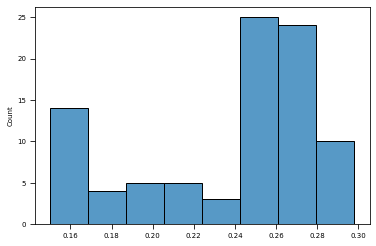

In [824]:
sns.histplot(model_full_pop.shifts[:, 3])

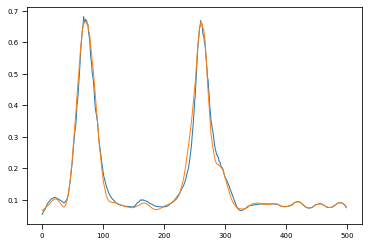

In [825]:
plt.plot(np.exp(model_full_pop.log_lmbd).mean(axis=1))
plt.plot(np.exp(model_nest_pop.log_lmbd).mean(axis=1))

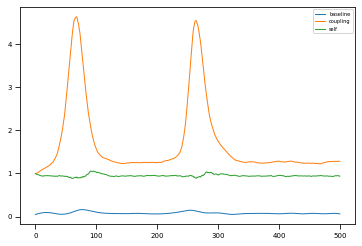

In [826]:
outputs = model_full_pop.get_filter_output()
plt.plot(np.exp(outputs[0]), label='baseline')
plt.plot(np.exp(outputs[1]), label='coupling')
plt.plot(np.exp(outputs[2]+outputs[3]), label='self')
plt.legend()

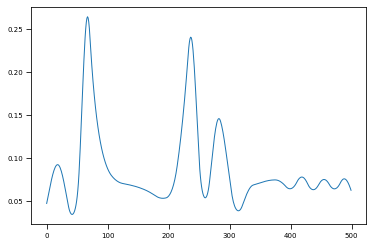

In [827]:
plt.plot(np.exp(model_full_pop.get_filter()[0]))

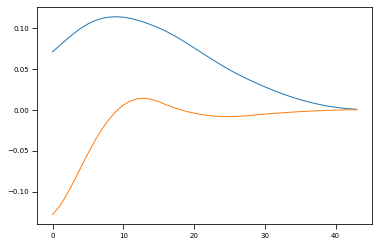

In [828]:
outputs = model_full_pop.get_filter()
plt.plot((outputs[1]))
plt.plot((outputs[2]))

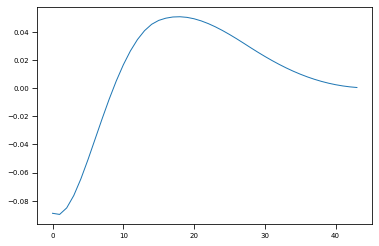

In [829]:
outputs = model_nest_pop.get_filter()
plt.plot((outputs[1]))


In [609]:
p = [res[1] for res in result]
p_pop = [res[1] for res in result_pop]

(0.0, 1.0)

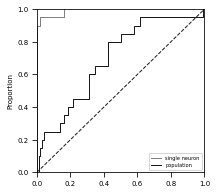

In [610]:
utils.use_pdf_plot()
plt.subplots(figsize=(3,3))
sns.ecdfplot(p, label="single neuron", color='grey')
sns.ecdfplot(p_pop, label="population", color='k')
plt.plot([np.max(p_pop),1], [1,1], color='k')
plt.legend()
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.plot([0,1], [0,1], '--', color='k')
# 1e5, 0.5e5 connect=0.007

plt.xlim([0,1])
plt.ylim([0,1])

# Check for penalty

## EIF neuron simulator

In [728]:
def getI(features, dt, nt, npadding):
    time_line = np.arange(-npadding, nt)*dt
    baseline = features["baseline"]
    features["I"] = np.zeros(len(time_line))+baseline
    for i in range(len(features["bump_amp"])):
        stimulus = (features["bump_amp"][i])*np.exp(-((time_line-features["bump_center"][i])/features["bump_wid"][i])**2)
        features["I"] += stimulus

In [731]:
def EIF_simulator(ntrial = 100):
    nneuron = 20
    dt = 0.1
    ndt = int(1/dt)
    nt = 500*ndt
    padding = 50
    npadding = padding*ndt
    nt_tot = nt + npadding
    noise_amp = 1

    J = np.zeros((nneuron, nneuron)) # From row i to column j
    nneuron_part = int(nneuron/2)
    J[0:nneuron_part,nneuron_part:] = 0.0
    J[0:nneuron_part,0:nneuron_part] = 0.0
    J[nneuron_part:,nneuron_part:] = 0.0

    baseline = 0.0
    bump_amp = 0.25
    bump_wid = 15
    source = {"baseline": baseline, 
              "bump_center": [50,250], 
              "bump_amp": [bump_amp,bump_amp], 
              "bump_wid": [bump_wid,bump_wid]}
    target = {"baseline": baseline, 
              "bump_center": [70,260], 
              "bump_amp": [bump_amp,bump_amp], 
              "bump_wid": [bump_wid,bump_wid]}
    getI(source, dt, nt, npadding)
    getI(target, dt, nt, npadding)
    I_ext = 0.0*np.ones((nt_tot, nneuron))
    I_ext[:,:nneuron_part] = np.repeat(source["I"][:,np.newaxis],nneuron_part, axis=1)
    I_ext[:,nneuron_part:] = np.repeat(target["I"][:,np.newaxis],nneuron_part, axis=1)

    # Unit: mV or ms
    tau = 15
    EL = -60
    VT = -50
    Vth = -10
    Vre = -65
    DltT = 2
    tau_ref = 1
    tau_d = 5
    tau_r = 1

    nsyn_func = 3*tau_d*ndt
    syn_time_line = np.arange(nsyn_func)
    syn_func = (np.exp(-syn_time_line*dt/tau_d)-np.exp(-syn_time_line*dt/tau_r))[:, np.newaxis]
    ntau_ref = tau_ref*ndt
    V_rcd = np.zeros((nt_tot, nneuron, ntrial))
    I_rcd = np.zeros((nt_tot+nsyn_func+1, nneuron, ntrial))
    spikes_rcd = np.zeros((nt_tot, nneuron, ntrial))

    for itrial in range(ntrial):
        V = Vre*np.ones((nt_tot, nneuron))
        I_syn = np.zeros((nt_tot+nsyn_func+1, nneuron))
        spikes = np.zeros((nt_tot, nneuron))

        for t in range(1, nt_tot):

            I_leak = -dt/tau*(V[t-1,:]-EL) + dt/tau*DltT*np.exp((V[t-1,:]-VT)/DltT)
            I_noise = np.random.normal(0, noise_amp**2, nneuron)
            dV = I_leak + I_noise + I_syn[t,:] + I_ext[t,:]
            V[t,:] = V[t-1,:] + dV

            spikes[t,:] = (V[t,:]>=Vth).astype(int)
            I_syn[(t+1):(t+nsyn_func+1),:] += spikes[t:(t+1),:]@J*syn_func

            in_ref = ((spikes[max(0,t-ntau_ref):(t+1),:].sum(axis=0))>0).astype(int)
            V[t,:] += in_ref*(Vre-V[t,:])

        V_rcd[:,:,itrial] = V
        I_rcd[:,:,itrial] = I_syn
        spikes_rcd[:,:,itrial] = spikes

    spikes_rcd = spikes_rcd.reshape((int(nt_tot/ndt),ndt,nneuron,ntrial), order='C').sum(axis=1)
    return spikes_rcd[padding:,:,:]

spikes_rcd = EIF_simulator()

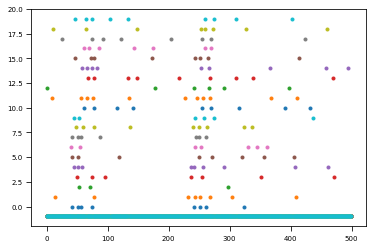

In [732]:
plt.plot(spikes_rcd[:,:,0]*np.arange(1,nneuron+1)-1, '.')

## Fit the two methods for 100 times

In [733]:
ntimes = 20
nfold = 10
penalty = 1e3
penalty_pop = 1e2
num = 30
num_pop = num
peaks_max = 7

tau = 10
num_f_refractory = 4

result = []
result_pop = []

for itimes in tqdm(range(ntimes)):
    test_nll_full = []
    test_nll_nest = []
    test_nll_full_pop = []
    test_nll_nest_pop = []
    nll_diff = 0
    nll_diff_pop = 0
    
    if itimes!=1:
        spikes_rcd = EIF_simulator()
    nt, nneuron, ntrial = spikes_rcd.shape
    
    spike_trains_source = []
    spike_trains_target = []
    time_line = np.arange(nt)
    
    for ineuron in range(nneuron):
        if ineuron < int(nneuron/2):
            spike_trains_source.append(spikes_rcd[:,ineuron,:])
        else:
            spike_trains_target.append(spikes_rcd[:,ineuron,:])
    
    kf = KFold(n_splits=nfold)
    for ifold, (train_index, test_index) in enumerate(kf.split(np.ones(ntrial))):
        
        training_trials = np.array( [False]*ntrial )
        training_trials[train_index] = True
        test_trials = np.logical_not(training_trials)

        ### Single neuron level model
        for output_spike_train in spike_trains_target:

            model_full = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_full.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
            for input_spike_train in spike_trains_source:
                model_full.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=peaks_max, nonlinear=1)
            for input_spike_train in spike_trains_target:
                model_full.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=peaks_max, nonlinear=1)
            model_full.fit(target=output_spike_train, method='mine', penalty=penalty, verbose=False)
            test_nll_full.append( model_full.test(test_trials) )

            model_nest = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_nest.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
            for input_spike_train in spike_trains_target:
                model_nest.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=peaks_max, nonlinear=1)
            model_nest.fit(target=output_spike_train, method='mine', penalty=penalty, verbose=False)
            test_nll_nest.append( model_nest.test(test_trials) )
            nll_diff += model_nest.nll - model_full.nll

        ### Population level model
        output_spike_train_pool = np.zeros((nt, ntrial))
        for output_spike_train in spike_trains_target:
            output_spike_train_pool += output_spike_train
        input_spike_train_pool = np.zeros((nt, ntrial))
        for input_spike_train in spike_trains_source:
            input_spike_train_pool += input_spike_train

        model_full_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_full_pop.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
        model_full_pop.add_effect("coupling", raw_input=input_spike_train_pool, num=3, peaks_max=peaks_max, nonlinear=1)
        model_full_pop.add_effect("coupling", raw_input=output_spike_train_pool, num=3, peaks_max=peaks_max, nonlinear=1)
        model_full_pop.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
                                  num=num_f_refractory, apply_no_penalty=True)
#         model_full_pop.fit(target=output_spike_train_pool, method='mine', penalty=penalty_pop, verbose=False)
        model_full_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, warp_interval=[[0, 0.5]], 
                                                 method='mine', penalty=penalty_pop, verbose=False)
        test_nll_full_pop.append( model_full_pop.test(test_trials) )

        model_nest_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_nest_pop.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
        model_nest_pop.add_effect("coupling", raw_input=output_spike_train_pool, num=3, peaks_max=peaks_max, nonlinear=1)
        model_nest_pop.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
                                  num=num_f_refractory, apply_no_penalty=True)
#         model_nest_pop.fit(target=output_spike_train_pool, method='mine', penalty=penalty_pop, verbose=False)
        model_nest_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, warp_interval=[[0, 0.5]], 
                                                 method='mine', penalty=penalty_pop, verbose=False)
        test_nll_nest_pop.append( model_nest_pop.test(test_trials) )
        nll_diff_pop += model_nest_pop.nll - model_full_pop.nll
    
    result.append( wilcoxon( test_nll_full, test_nll_nest, alternative='less') )
    result_pop.append( wilcoxon( test_nll_full_pop, test_nll_nest_pop, alternative='less') )

if ntimes == 1:
    print(f"Single neuron full:{np.mean(test_nll_full):.2f}")
    print(f"Single neuron nest:{np.mean(test_nll_nest):.2f}")
    print(f"Population full:{np.mean(test_nll_full_pop):.2f}")
    print(f"Population nest:{np.mean(test_nll_nest_pop):.2f}")

# result = wilcoxon( test_nll_full, test_nll_nest, alternative='less'),\
#             likelihood_ratio_test(nll_diff, ntimes*nneuron*3)
# result_pop = wilcoxon( test_nll_full_pop, test_nll_nest_pop, alternative='less'),\
#                 likelihood_ratio_test(nll_diff_pop, ntimes*3)

100%|█████████████████████████████████| 20/20 [1:08:10<00:00, 204.53s/it]


In [734]:
result, result_pop

([WilcoxonResult(statistic=2837.0, pvalue=0.858309999589689),
  WilcoxonResult(statistic=2837.0, pvalue=0.858309999589689),
  WilcoxonResult(statistic=2050.0, pvalue=0.051213017885905855),
  WilcoxonResult(statistic=2240.0, pvalue=0.16356216793772815),
  WilcoxonResult(statistic=2516.0, pvalue=0.48765673160816714),
  WilcoxonResult(statistic=2554.0, pvalue=0.5397132832439971),
  WilcoxonResult(statistic=2253.0, pvalue=0.1748363441707949),
  WilcoxonResult(statistic=2628.0, pvalue=0.638385811611983),
  WilcoxonResult(statistic=2716.0, pvalue=0.744319528477713),
  WilcoxonResult(statistic=2345.0, pvalue=0.2679916226436221),
  WilcoxonResult(statistic=3030.0, pvalue=0.9587493737981057),
  WilcoxonResult(statistic=1924.0, pvalue=0.019393795433784288),
  WilcoxonResult(statistic=2777.0, pvalue=0.8068804372007918),
  WilcoxonResult(statistic=3033.0, pvalue=0.959652616441178),
  WilcoxonResult(statistic=2763.0, pvalue=0.793413130271049),
  WilcoxonResult(statistic=3441.0, pvalue=0.99918226500

In [735]:
p = [res[1] for res in result]
p_pop = [res[1] for res in result_pop]

In [736]:
np.mean(p), np.mean(p_pop)

(0.6072484899035887, 0.362451171875)

(0.0, 1.0)

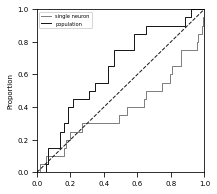

In [737]:
utils.use_pdf_plot()
plt.subplots(figsize=(3,3))
sns.ecdfplot(p, label="single neuron", color='grey')
sns.ecdfplot(p_pop, label="population", color='k')
plt.plot([np.max(p_pop),1], [1,1], color='k')
plt.legend()
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.plot([0,1], [0,1], '--', color='k')
# 1e5, 0.5e5 connect=0.007

plt.xlim([0,1])
plt.ylim([0,1])